# 💨 Chương 4 — Dataset 1: Beijing Air Quality — Multivariate LSTM
## Kỹ thuật: Multivariate Time Series + LSTM + Sliding Window

**Pipeline:** EDA → Correlation Analysis → Sliding Window → Multivariate LSTM → Train → Forecast Visualization

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob, os, warnings

import random

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/beijing_air_quality'
SAVE_DIR = '../results/beijing_air_quality'
os.makedirs(SAVE_DIR, exist_ok=True)

LOOK_BACK  = 24   # 24 giờ ngữ cảnh của chuỗi thời gian
EPOCHS     = 30
BATCH_SIZE = 64
TARGET_COL = 'pm2.5'

print(f'TF: {tf.__version__}')

I0000 00:00:1780117895.476279 1871767 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780117895.511629 1871767 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0


I0000 00:00:1780117896.284404 1871767 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 📂 1. Load & Tổng quan Data

In [2]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)

# Load and combine if multiple files
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Found: ['../data/beijing_air_quality/PRSA_data_2010.1.1-2014.12.31.csv', '../data/beijing_air_quality/PRSA_data_2010.1.1-2014.12.31.csv']
Shape: (87648, 13)
Columns: ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
5,6,2010,1,1,5,NaN,-19,-10.0,1017.0,NW,16.10,0,0
6,7,2010,1,1,6,NaN,-19,-9.0,1017.0,NW,19.23,0,0
7,8,2010,1,1,7,NaN,-19,-9.0,1017.0,NW,21.02,0,0
8,9,2010,1,1,8,NaN,-19,-9.0,1017.0,NW,24.15,0,0
9,10,2010,1,1,9,NaN,-20,-8.0,1017.0,NW,27.28,0,0


In [3]:
# 1. Handle target column (pm2.5)
TARGET_COL = 'pm2.5'
df = df.dropna(subset=[TARGET_COL])

# 2. Build datetime index directly
df.index = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
print('Datetime index set successfully')

# 3. Check for remaining missing values
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0]
if not missing_info.empty:
    print(f'\nMissing values found:\n{missing_info}')
else:
    print('\nNo missing values remaining.')

Datetime index set successfully

No missing values remaining.


## 📊 2. EDA — Phân tích Chuỗi Thời gian

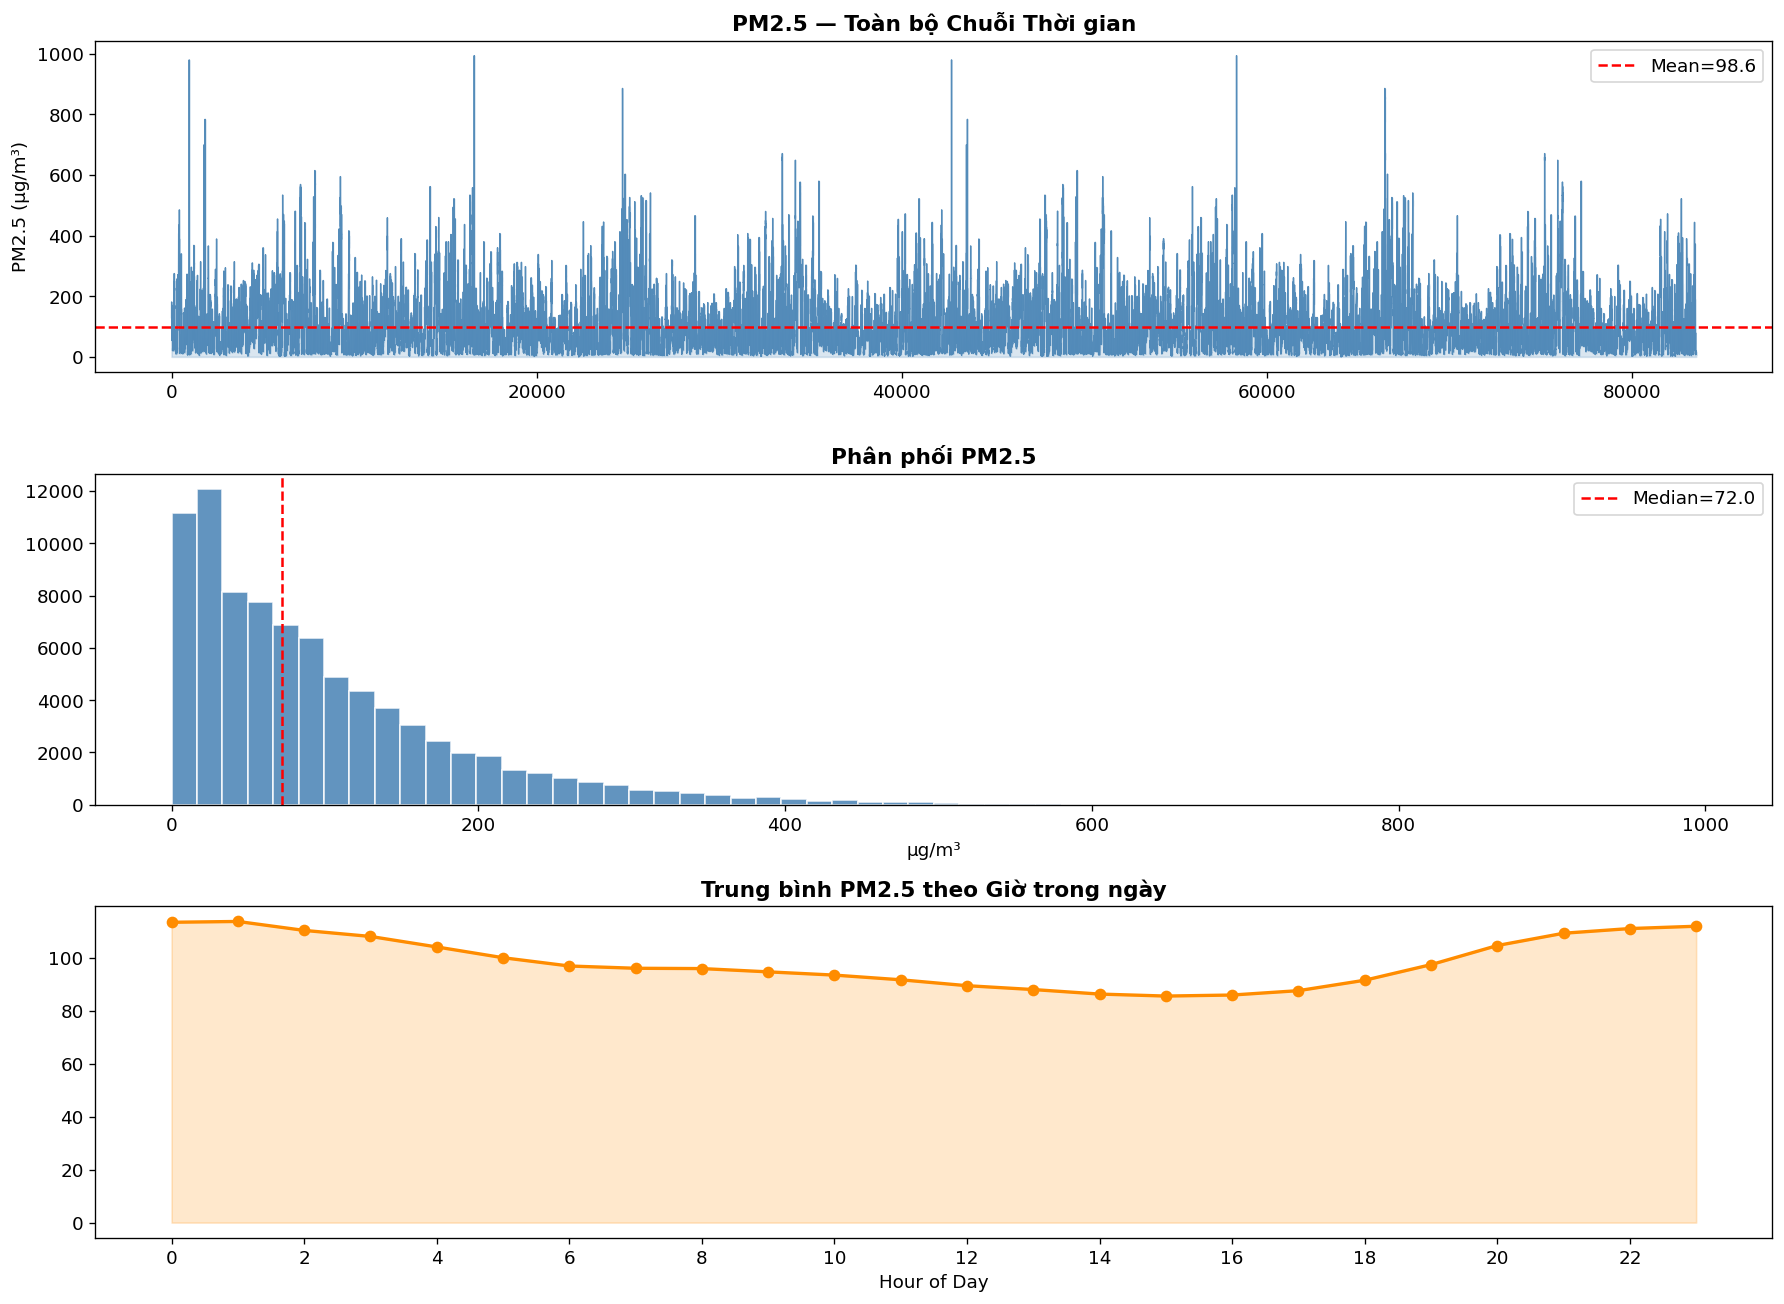

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# PM2.5 over time
axes[0].plot(df[TARGET_COL].values, color='steelblue', lw=0.8, alpha=0.9)
axes[0].fill_between(range(len(df)), df[TARGET_COL].values, alpha=0.2, color='steelblue')
axes[0].axhline(df[TARGET_COL].mean(), color='red', linestyle='--', lw=1.5, label=f'Mean={df[TARGET_COL].mean():.1f}')
axes[0].set_title(f'{TARGET_COL.upper()} — Toàn bộ Chuỗi Thời gian')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()

# Distribution
axes[1].hist(df[TARGET_COL].values, bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].axvline(df[TARGET_COL].median(), color='red', linestyle='--',
                label=f'Median={df[TARGET_COL].median():.1f}')
axes[1].set_title(f'Phân phối {TARGET_COL.upper()}')
axes[1].set_xlabel('µg/m³')
axes[1].legend()

# Monthly/hourly pattern (if datetime available)
try:
    if hasattr(df.index, 'hour'):
        hourly_avg = df.groupby(df.index.hour)[TARGET_COL].mean()
        axes[2].plot(hourly_avg.index, hourly_avg.values, 'o-', color='darkorange', lw=2)
        axes[2].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='darkorange')
        axes[2].set_title('Trung bình PM2.5 theo Giờ trong ngày')
        axes[2].set_xlabel('Hour of Day')
        axes[2].set_xticks(range(0, 24, 2))
    else:
        raise ValueError()
except:
    rolling = pd.Series(df[TARGET_COL].values).rolling(window=24*7).mean()
    axes[2].plot(df[TARGET_COL].values, alpha=0.3, color='steelblue', lw=0.5, label='Raw')
    axes[2].plot(rolling, color='darkorange', lw=2, label='7-day Rolling Mean')
    axes[2].set_title('Raw vs Rolling Mean')
    axes[2].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_time_series_eda.png', bbox_inches='tight')
plt.show()

Feature columns: ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']


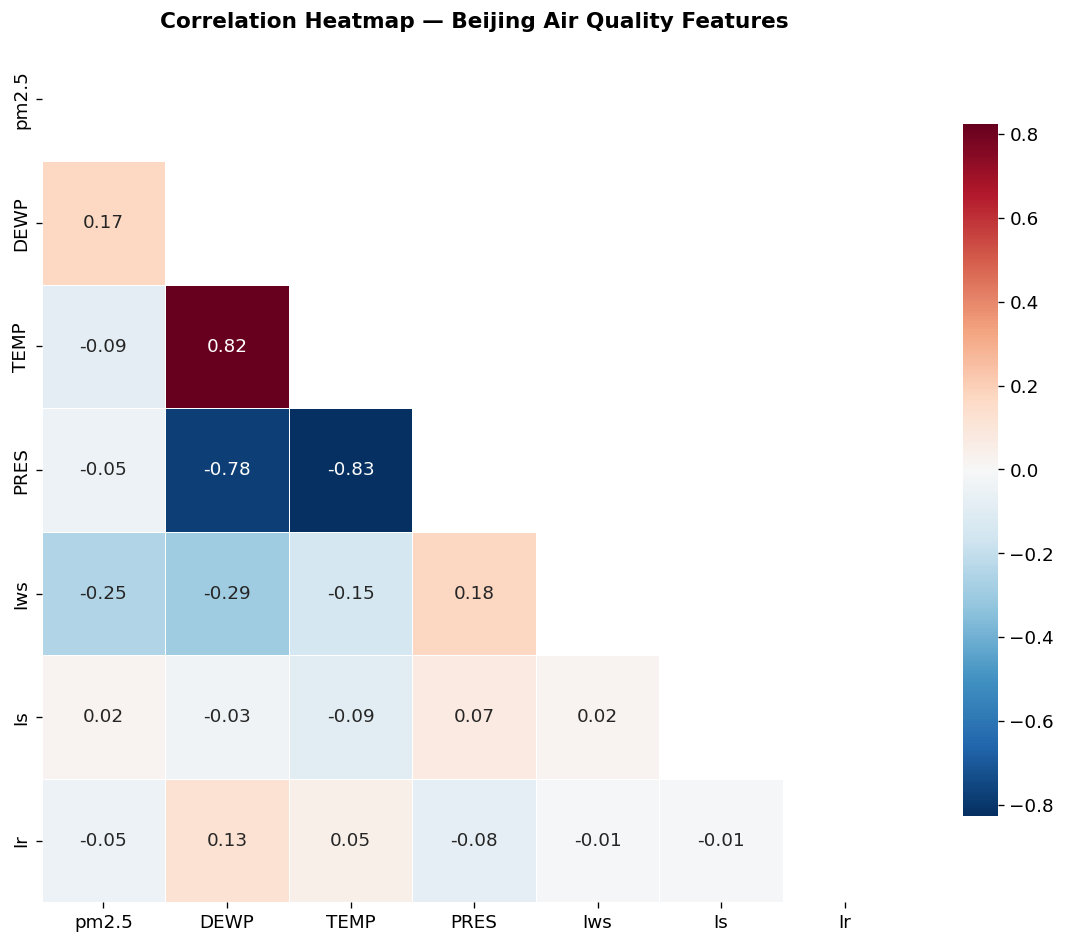

In [5]:
# Select numeric features for multivariate
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove non-feature columns
drop_cols = ['year','month','day','hour','No']
feature_cols = [c for c in numeric_cols if c.lower() not in [d.lower() for d in drop_cols]]
df_feat = df[feature_cols].copy().fillna(method='ffill').fillna(0)

print(f'Feature columns: {feature_cols}')

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Beijing Air Quality Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing — Sliding Window

In [6]:
# Scale all features
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_feat.values)

target_idx = feature_cols.index(TARGET_COL) if TARGET_COL in feature_cols else 0

def create_multivariate_dataset(data, look_back, target_idx):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, :])        # All features as input
        y.append(data[i+look_back, target_idx]) # Only target as output
    return np.array(X), np.array(y)

X_all, y_all = create_multivariate_dataset(data_scaled, LOOK_BACK, target_idx)

split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f'X shape: {X_all.shape}  → (samples, look_back={LOOK_BACK}, features={X_all.shape[2]})')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

X shape: (83490, 24, 7)  → (samples, look_back=24, features=7)
Train: (66792, 24, 7), Test: (16698, 24, 7)


## 🏗️ 4. Multivariate LSTM Model

In [7]:
n_features = X_train.shape[2]

model = models.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, n_features), name='lstm_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False, name='lstm_2'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, name='forecast')
], name='MultivariateLSTM_AirQuality')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse',
              metrics=['mae'])
model.summary()

I0000 00:00:1780117905.025522 1871767 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 41762 MB memory:  -> device: 0, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780117905.027083 1871767 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46629 MB memory:  -> device: 1, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1780117905.305407 1871767 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 7754 MB memory:  -> device: 2, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:83:00.0, compute capability: 8.9


Model: "MultivariateLSTM_AirQuality"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,665 (475.25 KB)

 Trainable params: 121,409 (474.25 KB)

 Non-trainable params: 256 (1.00 KB)

## 🚀 5. Training

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

Epoch 1/30


I0000 00:00:1780117908.463923 1872512 cuda_dnn.cc:461] Loaded cuDNN version 92101


940/940 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0031 - mae: 0.0362 - val_loss: 0.0026 - val_mae: 0.0386 - learning_rate: 0.0010
Epoch 2/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0011 - mae: 0.0223 - val_loss: 0.0017 - val_mae: 0.0305 - learning_rate: 0.0010
Epoch 3/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9.1916e-04 - mae: 0.0199 - val_loss: 0.0013 - val_mae: 0.0254 - learning_rate: 0.0010
Epoch 4/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.6068e-04 - mae: 0.0191 - val_loss: 0.0012 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 5/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.3786e-04 - mae: 0.0187 - val_loss: 9.4972e-04 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 6/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.1217e-04 - mae: 0.0182 - val_loss: 9.2014e-04 - val_mae: 0.0211 - learning_rate: 0.0010
Epoch 7/30
940/940 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 7.9112e-04 - mae: 0.0180 - val_loss: 9.1195e-04 - val_mae: 0.0209 - learnin

## 📈 6. Forecast Visualization & Evaluation

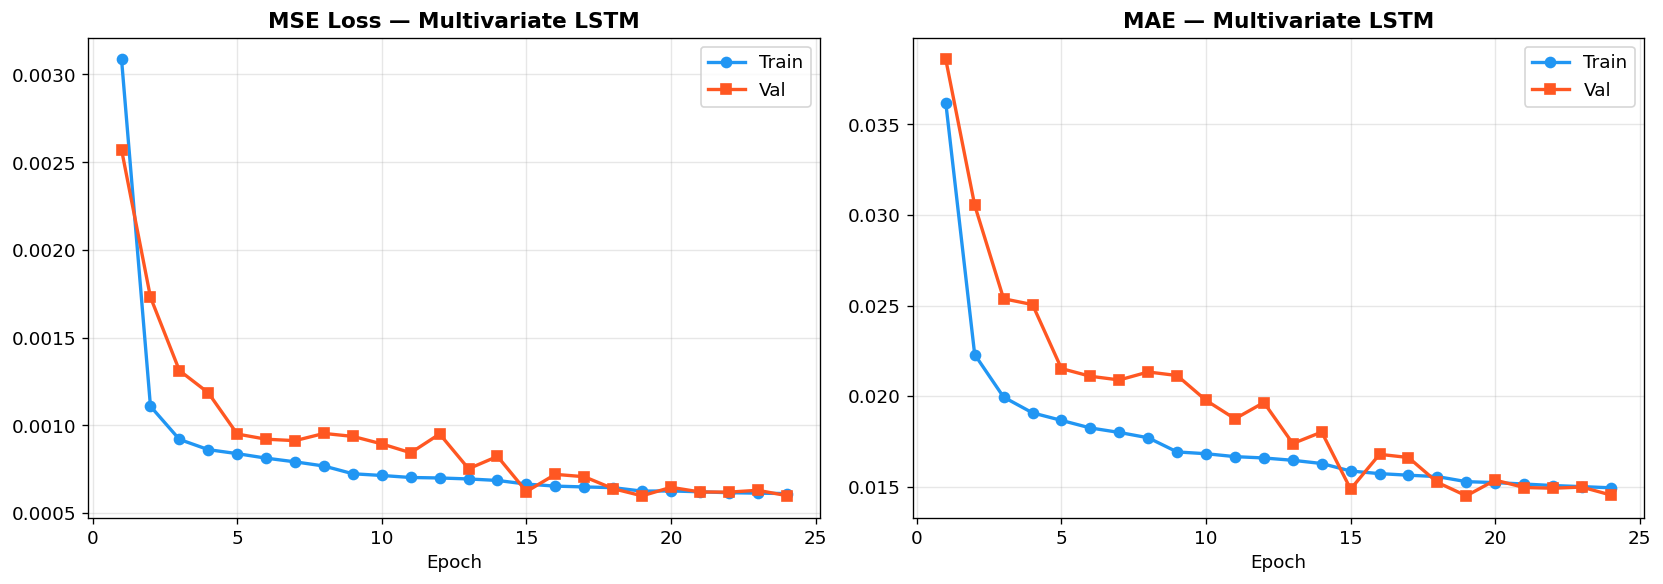

In [9]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['loss'])+1)

for ax, (tr, vl, metric) in zip(axes, [
    ('loss','val_loss','MSE Loss'),
    ('mae','val_mae','MAE')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.set_title(f'{metric} — Multivariate LSTM')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

In [10]:
# Inverse-transform predictions back to original scale
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Build dummy matrix to inverse transform only target column
dummy = np.zeros((len(y_pred_scaled), n_features))
dummy[:, target_idx] = y_pred_scaled
y_pred_orig = scaler.inverse_transform(dummy)[:, target_idx]

dummy2 = np.zeros((len(y_test), n_features))
dummy2[:, target_idx] = y_test
y_test_orig = scaler.inverse_transform(dummy2)[:, target_idx]

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae  = mean_absolute_error(y_test_orig, y_pred_orig)
r2   = r2_score(y_test_orig, y_pred_orig)

print(f'RMSE : {rmse:.4f} µg/m³')
print(f'MAE  : {mae:.4f} µg/m³')
print(f'R²   : {r2:.4f}')

RMSE : 22.7316 µg/m³
MAE  : 13.8820 µg/m³
R²   : 0.9373


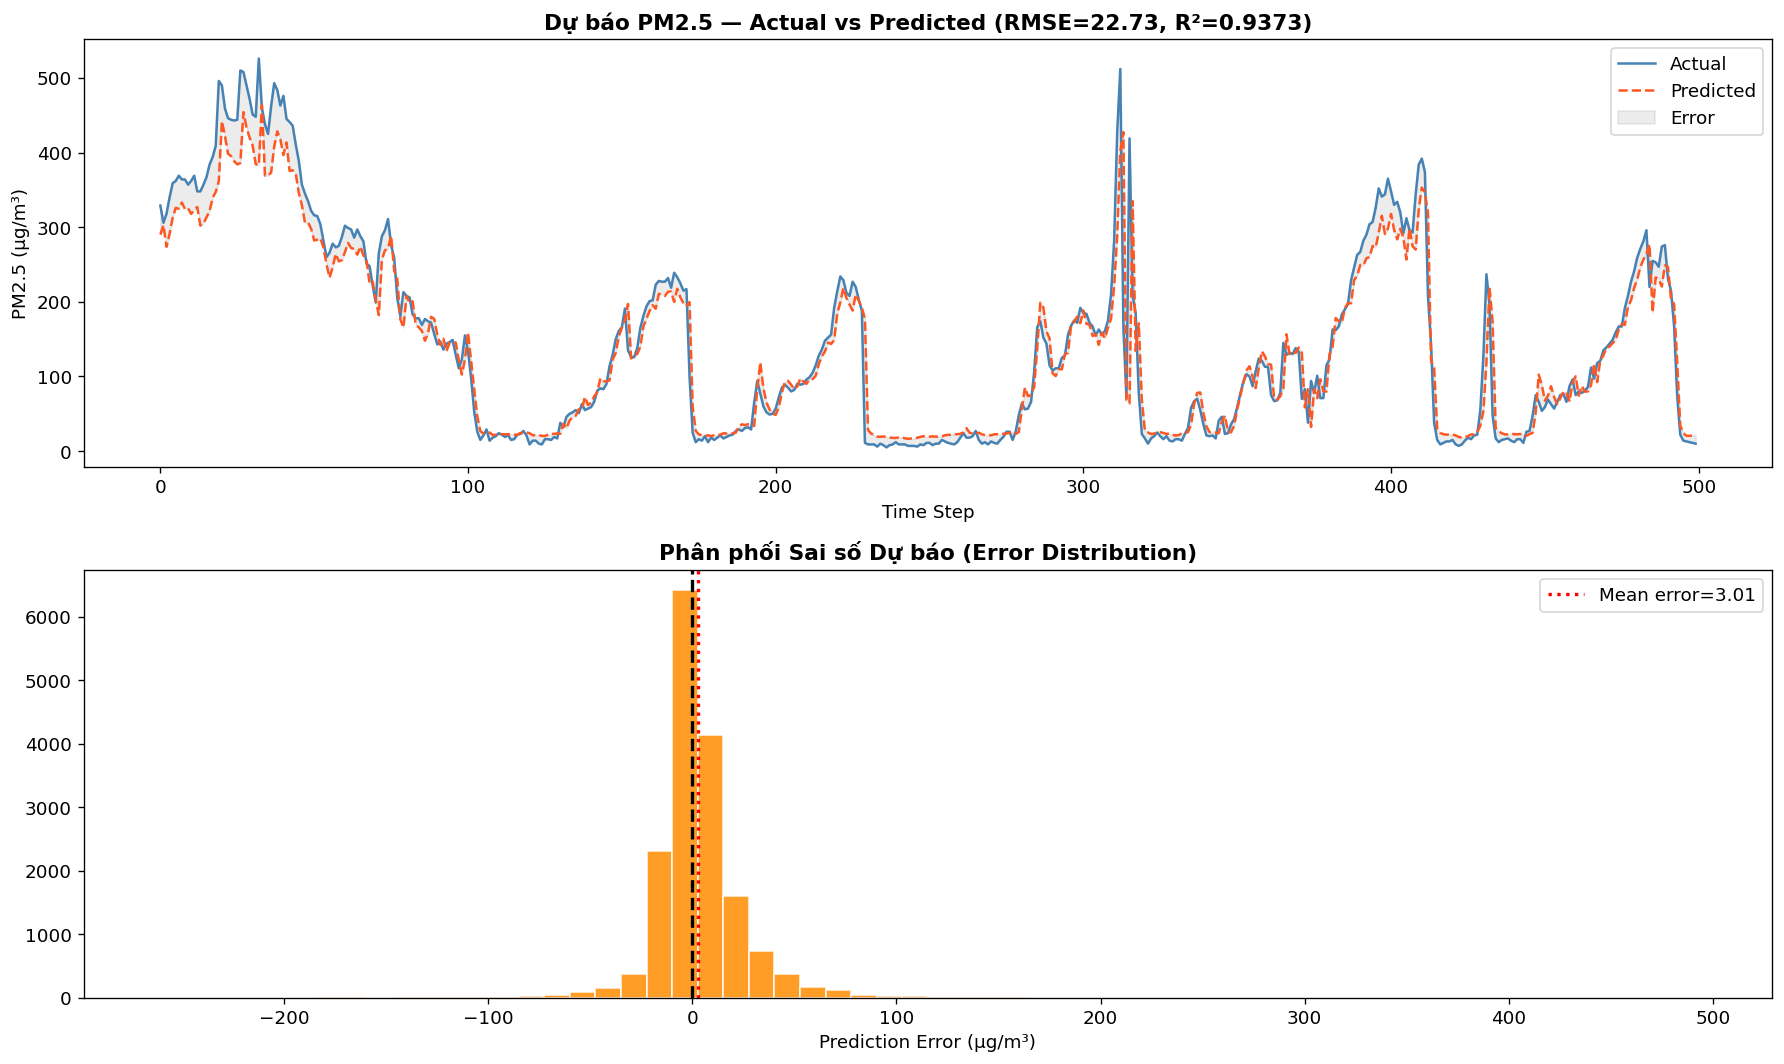

In [11]:
# Forecast vs Actual plot
show_n = min(500, len(y_test_orig))

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Time series
axes[0].plot(y_test_orig[:show_n], color='steelblue', lw=1.5, label='Actual')
axes[0].plot(y_pred_orig[:show_n], color='#FF5722', lw=1.5, linestyle='--', label='Predicted')
axes[0].fill_between(range(show_n), y_test_orig[:show_n], y_pred_orig[:show_n],
                     alpha=0.15, color='gray', label='Error')
axes[0].set_title(f'Dự báo PM2.5 — Actual vs Predicted (RMSE={rmse:.2f}, R²={r2:.4f})')
axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()

# Error distribution
errors = y_test_orig - y_pred_orig
axes[1].hist(errors, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].axvline(errors.mean(), color='red', linestyle=':', lw=2, label=f'Mean error={errors.mean():.2f}')
axes[1].set_title('Phân phối Sai số Dự báo (Error Distribution)')
axes[1].set_xlabel('Prediction Error (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_forecast_vs_actual.png', bbox_inches='tight')
plt.show()

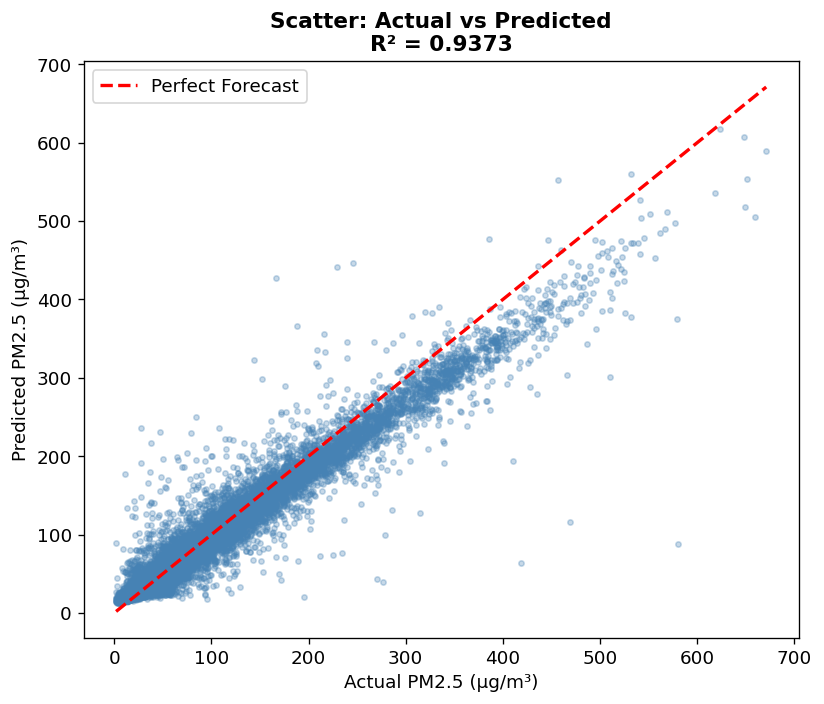

In [12]:
# Scatter: Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10, color='steelblue')
mn, mx = min(y_test_orig.min(), y_pred_orig.min()), max(y_test_orig.max(), y_pred_orig.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Forecast')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Scatter: Actual vs Predicted\nR² = {r2:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_scatter_actual_vs_pred.png', bbox_inches='tight')
plt.show()

In [13]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Beijing Air Quality — Multivariate LSTM\n' + '='*50 + '\n')
    f.write(f'LOOK_BACK     : {LOOK_BACK} hours\n')
    f.write(f'Features      : {feature_cols}\n')
    f.write(f'Total Params  : {model.count_params():,}\n\n')
    f.write(f'Test RMSE     : {rmse:.4f} µg/m³\n')
    f.write(f'Test MAE      : {mae:.4f} µg/m³\n')
    f.write(f'Test R²       : {r2:.4f}\n')

print('✅ Beijing Air Quality Multivariate LSTM Done! Saved to', SAVE_DIR)

✅ Beijing Air Quality Multivariate LSTM Done! Saved to ../results/beijing_air_quality
